# Model

In [1]:
from topological_insulator import Problem

structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"
material_path = "../../../../../topological_insulator/data/cases/"
material_name = "germanene.json"

problem = Problem(structure_path=structure_path, structure_name=structure_name,
                  material_path=material_path, material_name=material_name
)

In [2]:
eigenvalue_dict = problem.cell_parser.eigenvalue_dict["eigenvalues"]
# problem.cell_parser.eigenvalue_dict["buckling_cosine"] = 0
eigenvalue_dict["t_ss_sigma"] = -0.05
# eigenvalue_dict["t_sp_sigma"] = 0.5
eigenvalue_dict["t_pp_sigma"] = 1
eigenvalue_dict["t_pp_pi"] = 1

eigenvalue_dict["E_s"] = -5
eigenvalue_dict["E_p"] =0

# eigenvalue_dict["Delta_pp"] = 34e-3
# # eigenvalue_dict["lambda_ss"] = -1e-6 #-0.1 #43e-3
# eigenvalue_dict["lambda_pp"] = 3.97e-3

In [3]:
location = "edge"
problem.setup(
    N_r = 22, # size of lattice in real space
    N_k = 400, # reciprocal space discretization
    location = location,
    BZ="extended"
)

Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.


In [4]:
g = problem.geometry
tb_edge = problem.hamiltonian[location]["tight_binding"]

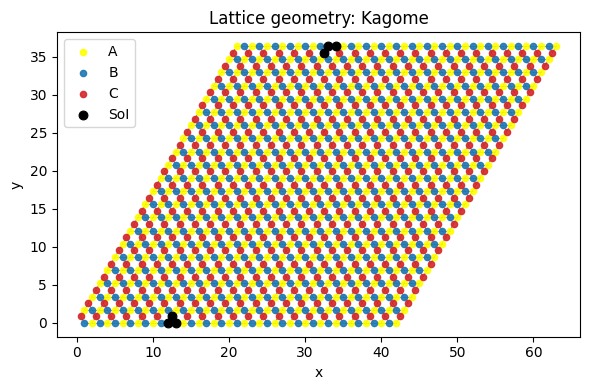

In [5]:
edge_sites = [0, 1, 2, -3, -2, -1]
g.plot_lattice(tb_edge.sublattice_idxs[edge_sites])

In [6]:
problem.run(
    H_type="reciprocal"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!


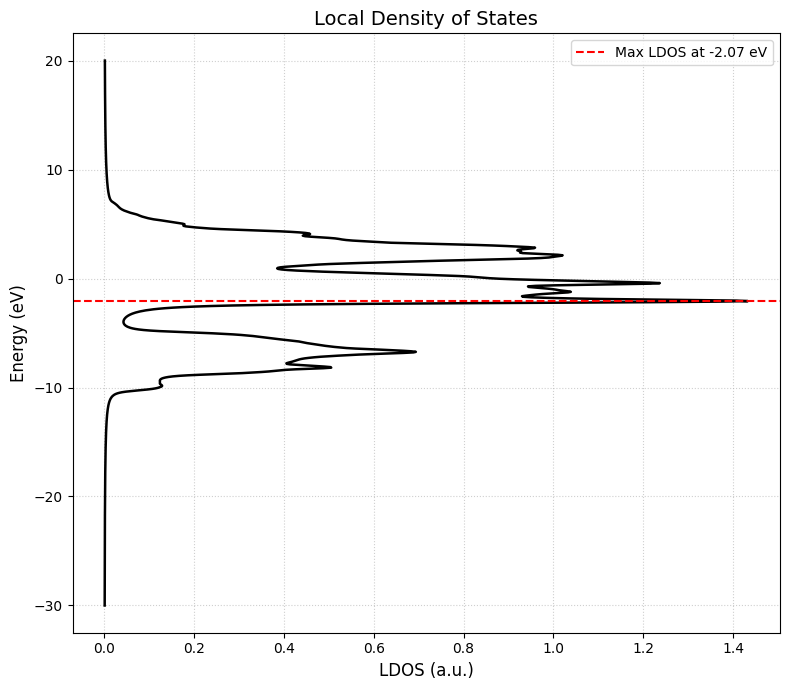

In [7]:
invariants = problem.hamiltonian["edge"]["topological_invariants"]
LDOS, E = invariants.get_local_density_of_states(
    site_idx = 0,
    E_max = 20,#8, 
    E_min = -30,#-12,
    eta = 0.15
)

invariants.plot_density_of_states(LDOS, E)

In [11]:
import numpy as np
k_target = np.pi/2
edge_bands = tb_edge.get_edge_bands(g, edge_sites=edge_sites, k_target=k_target, threshold=0.3)
print(edge_bands)

[np.int64(86), np.int64(119), np.int64(280), np.int64(281), np.int64(306), np.int64(307), np.int64(354), np.int64(355), np.int64(358), np.int64(359), np.int64(400), np.int64(427), np.int64(470), np.int64(473)]


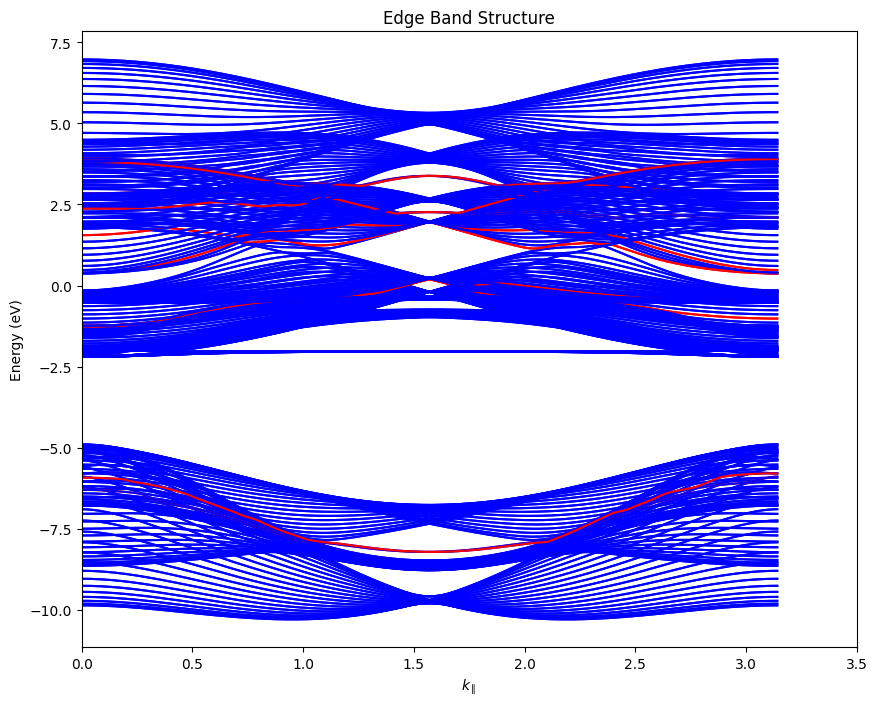

In [12]:
tb_edge.plot_dispersion(g, edge_bands=edge_bands, x_max=3.5, x_min=0)

Total norm: 1.000000


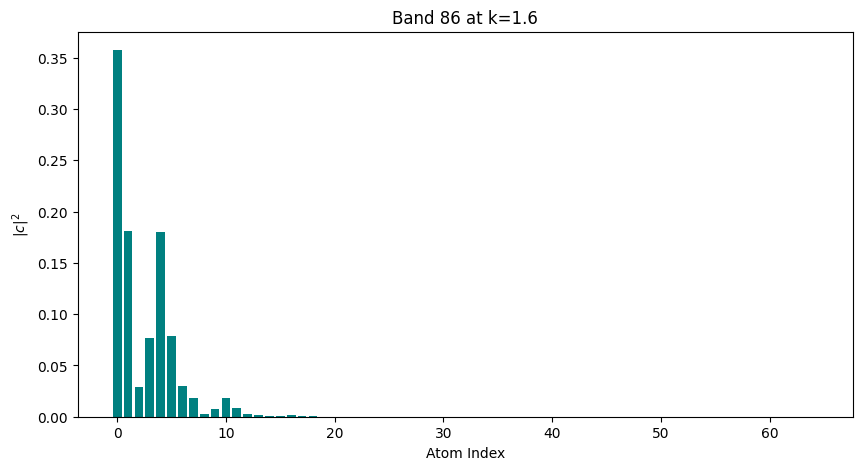

Total norm: 1.000000


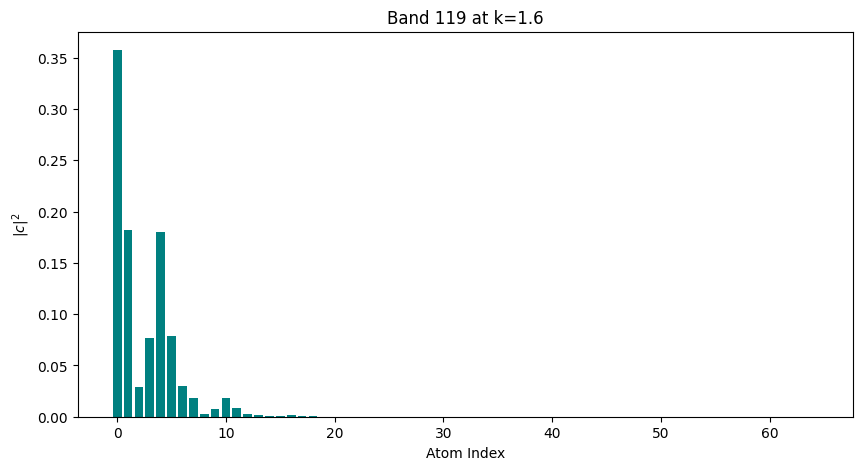

Total norm: 1.000000


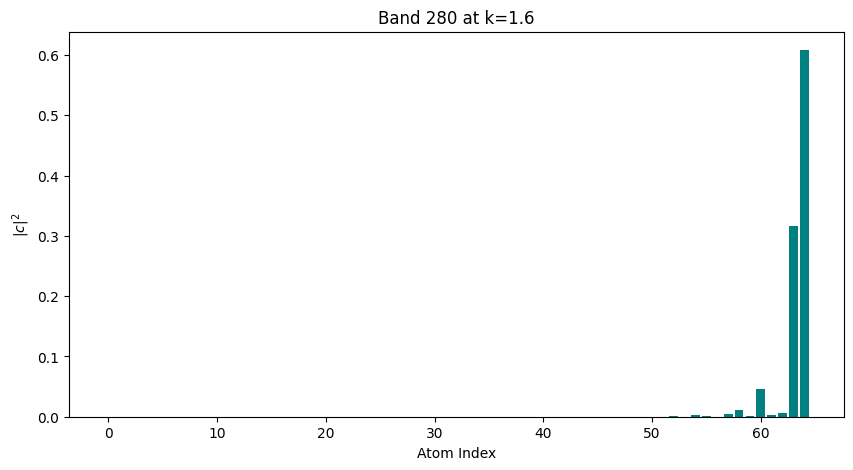

Total norm: 1.000000


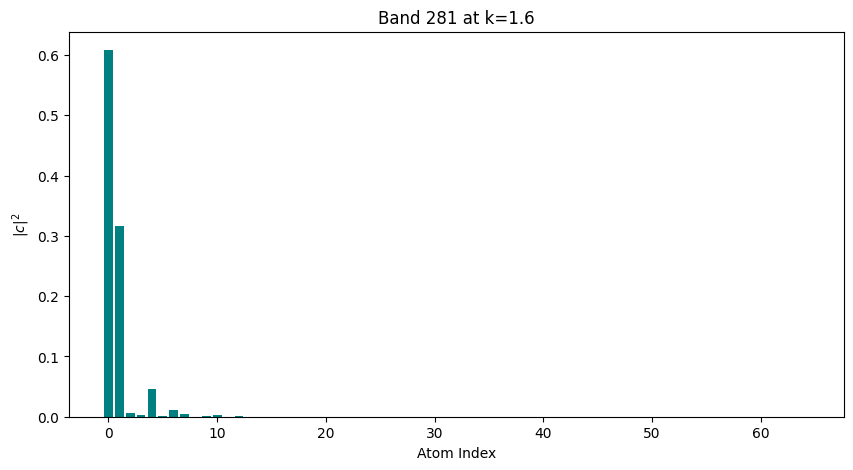

Total norm: 1.000000


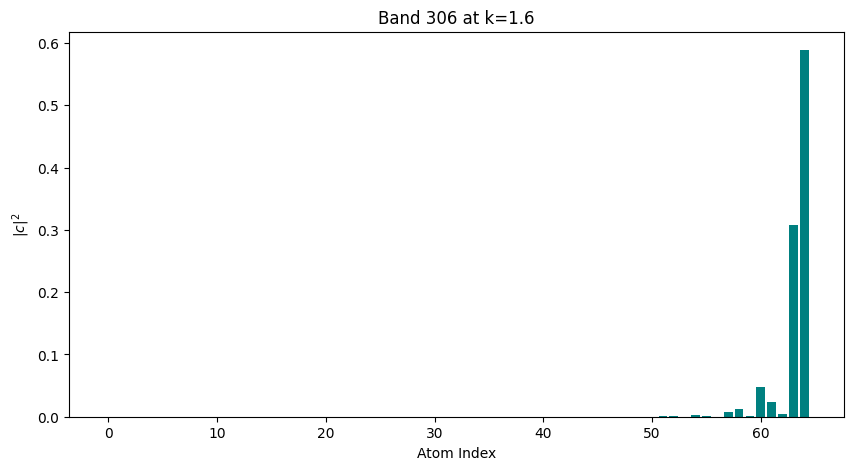

Total norm: 1.000000


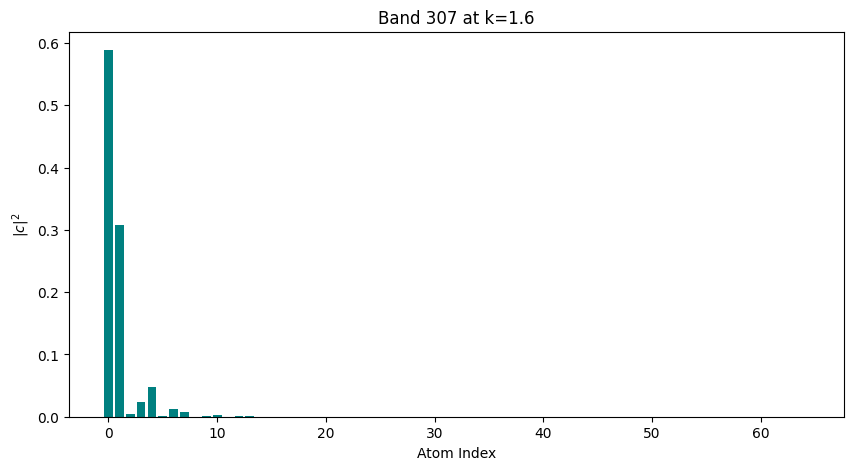

Total norm: 1.000000


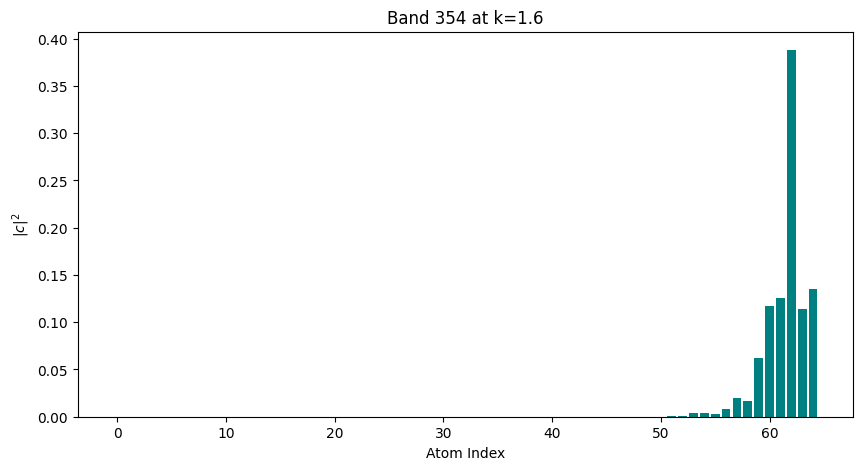

Total norm: 1.000000


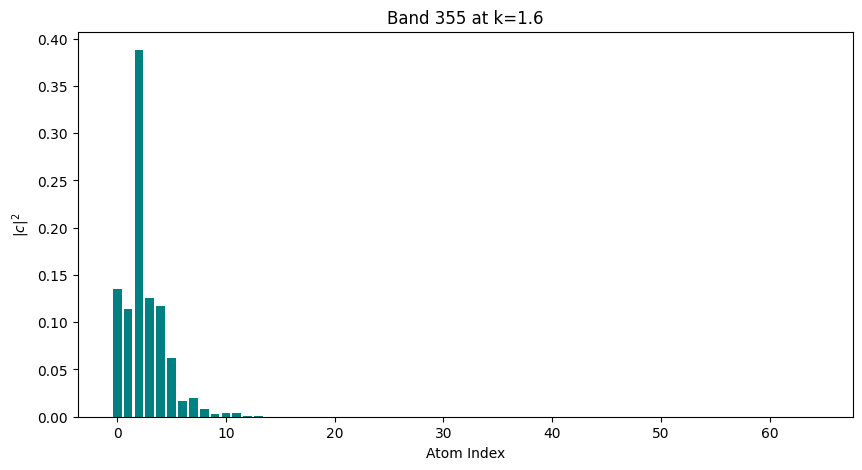

Total norm: 1.000000


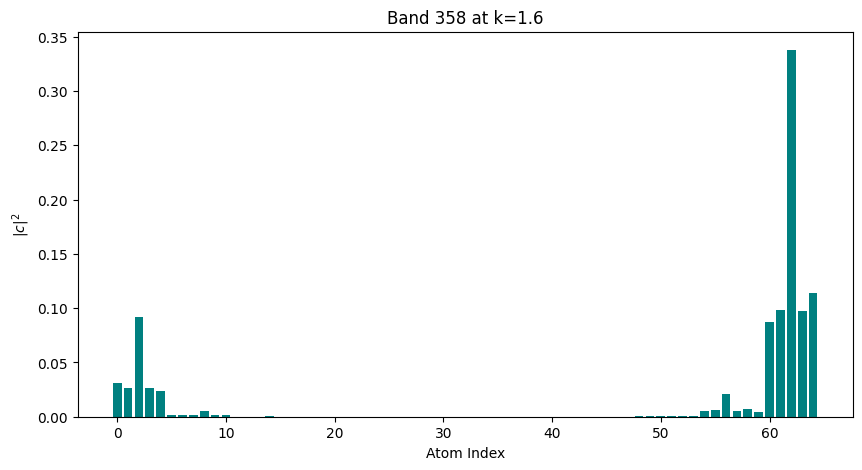

Total norm: 1.000000


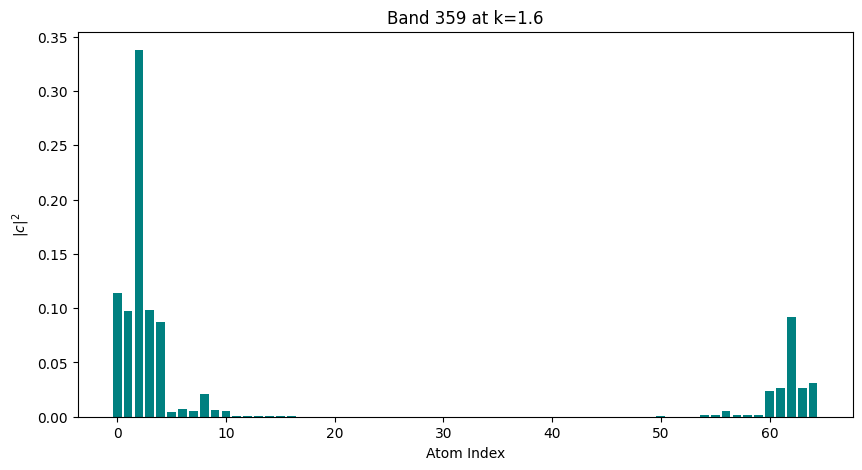

Total norm: 1.000000


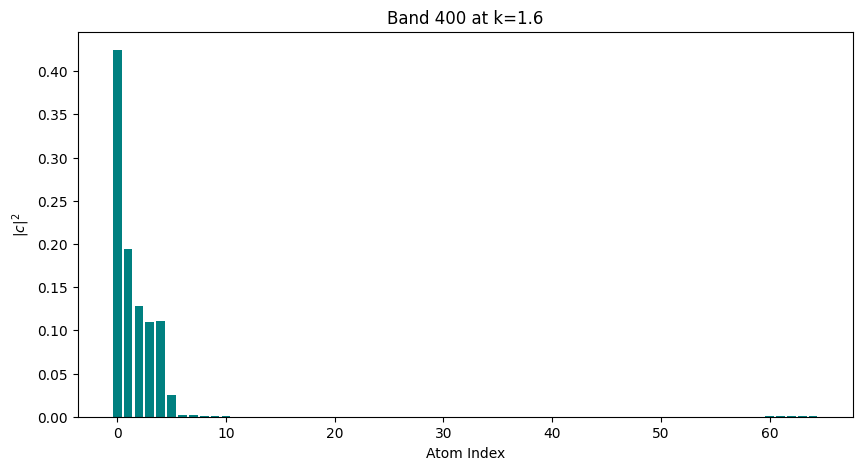

Total norm: 1.000000


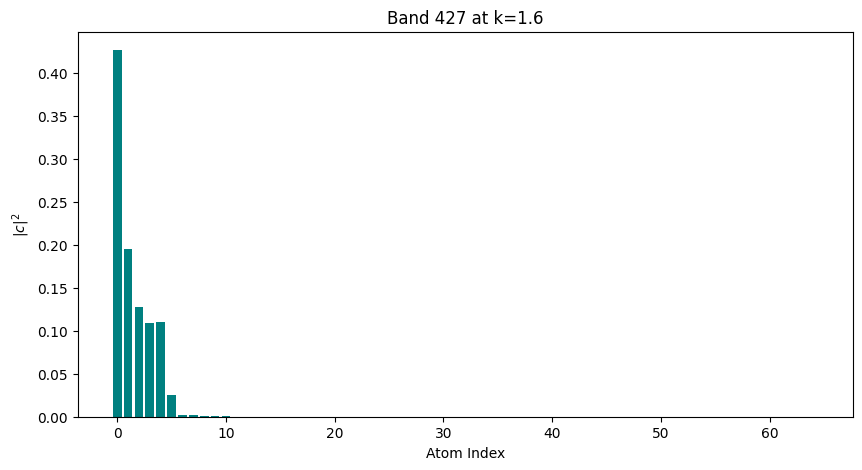

Total norm: 1.000000


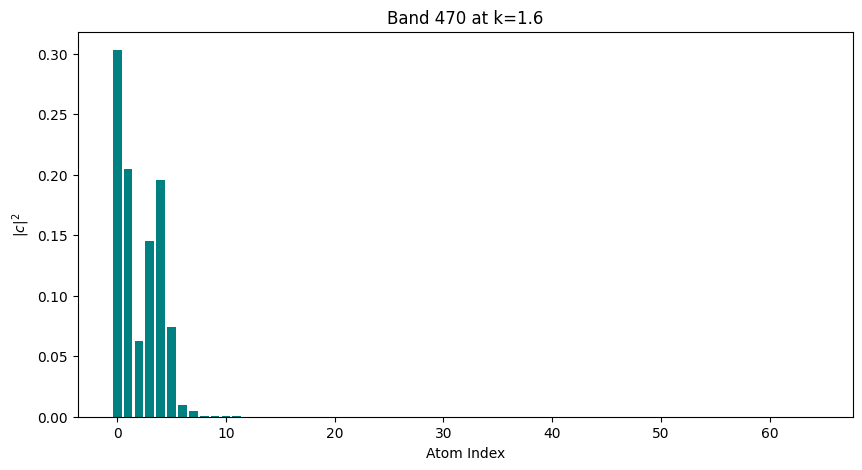

Total norm: 1.000000


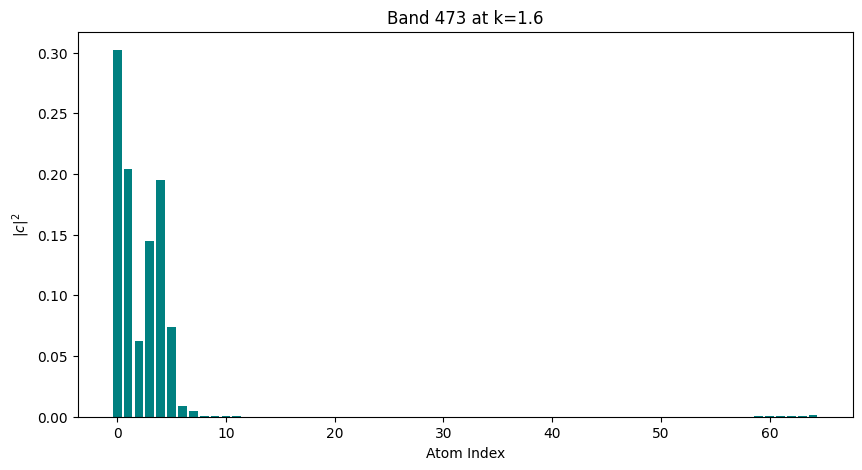

In [13]:
N_projections = len(tb_edge.coupled_states)
N_sites = len(tb_edge.sublattice_idxs)
N_bands = N_sites * N_projections

Psi_dict = tb_edge.band_structure_data["eigenvector_dict"]
for band in edge_bands:
    k_idx = np.argmin(np.abs(g.k_edge - k_target))
    Psi_k = Psi_dict[band][k_idx, :]
    total_norm = np.sum(np.abs(Psi_k)**2)
    print(f"Total norm: {total_norm:.6f}")
    n_atoms = len(tb_edge.sublattice_idxs)
    atomic_wavefunctions = {}
    atom_contributions = np.zeros(n_atoms)
    for i in range(n_atoms):
        start = i * N_projections
        end = start + N_projections
        orbital_block = Psi_k[start:end]  # Orbitals for atom i
        atom_contributions[i] = np.sum(np.abs(orbital_block)**2)
        atomic_wavefunctions[i] = Psi_k[start:end] 

    from matplotlib import pyplot as plt
    plt.figure(figsize=(10, 5))
    plt.bar(range(n_atoms), atom_contributions, color='teal')
    plt.xlabel("Atom Index")
    plt.ylabel(f"$|c|^2$")
    # plt.xlim(0, 10)
    plt.title(f"Band {band} at k={np.abs(g.k_edge[k_idx]):.1f}")
    plt.show()